In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# ---------- Configuração estilo científico ----------
plt.rcParams.update({
    "font.size": 15,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False
})

# Rede unidimensional

(-3.141592653589793, 3.141592653589793)

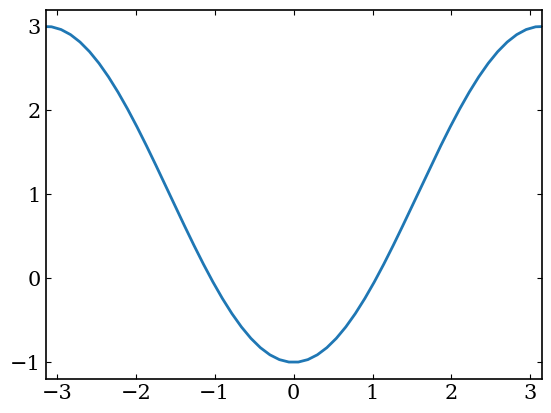

In [8]:
e0 = 1
t = 1
a = 3
k = np.linspace(-10,10,500)
E = e0 - 2*t*np.cos(k*a)

plt.plot(k*a, E)
plt.xlim(-np.pi, np.pi)

# Rede grafeno

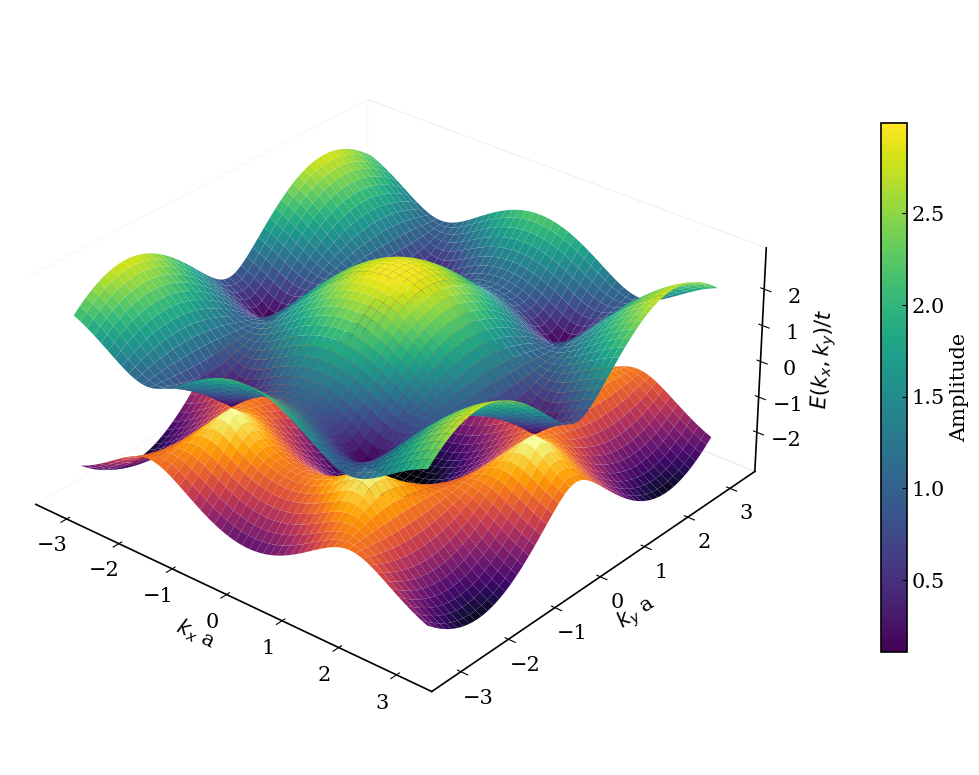

In [19]:
N = 1# numero de sítios
e0 = 0 # energia do nivel
delta_e = 0 # integral de transferencia do mesmo sítio
t1 = 1 # taxa de salto para primeiro vizinho
t2 = 0*t1 # taxa de salto para segundo vizinho
#kx = np.linspace(-np.pi+0.7,np.pi-0.7,300) # eixo kx
#ky = np.linspace(-np.pi+1,np.pi-1,300) # eixo ky
kx = np.linspace(-np.pi,np.pi,300) # eixo kx
ky = np.linspace(-np.pi,np.pi,300) # eixo ky
#kx = np.pi-1.9
#ky = 0 #2.1
a = 1 # distancia interatomica
delta = 0 # integral de overlap

kx, ky = np.meshgrid(kx,ky)
gamma_k = np.abs(np.sqrt(3 + 4*np.cos((np.sqrt(3)/2)*kx*a)*np.cos((3/2)*ky*a) + 2*np.cos(np.sqrt(3)*kx*a)))

E_plus = N*((e0 + delta_e) + t2*(gamma_k**2 - 3)) + N*(e0*delta + t1)*gamma_k
E_minus = N*((e0 + delta_e) + t2*(gamma_k**2 - 3)) - N*(e0*delta + t1)*gamma_k

# ---------- figura ----------
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
ax.set_box_aspect([1,1,0.5])

# ---------- superfície ----------
surf1 = ax.plot_surface(kx*a, ky*a, E_plus/t1,
                        cmap='viridis',
                        edgecolor='none',   # remove linhas (importante!)
                        antialiased=True)
surf2 = ax.plot_surface(kx*a, ky*a, E_minus/t1,
                        cmap='inferno',
                        edgecolor='none',   # remove linhas (importante!)
                        antialiased=True)

# ---------- colorbar ----------
cbar = fig.colorbar(surf1, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label(r'Amplitude')

ax.set_xlabel(r'$k_x$ a')
ax.set_ylabel(r'$k_y$ a')
ax.set_zlabel(r'$E(k_x, k_y)/t$')

# ---------- ângulo de visão ----------
ax.view_init(elev=30, azim=-50)

# ---------- layout ----------
plt.tight_layout()
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
# ---------- salvar ----------
plt.savefig("figura.png", dpi=600, bbox_inches='tight')

# Para plotar recortes do grafico
# plt.plot(kx*a, ky*a, E_plus/t1)
# plt.plot(kx*a, ky*a,E_minus/t1)



In [87]:
min = np.min(E_plus/t1)
max = np.max(E_minus/t1)
print(min, max)
min-max

0.0054255464497448775 -0.0054255464497448775


0.010851092899489755

In [14]:
ev_plus = np.sort(E_plus.flatten()/t1)
print(len(ev_plus))

90000


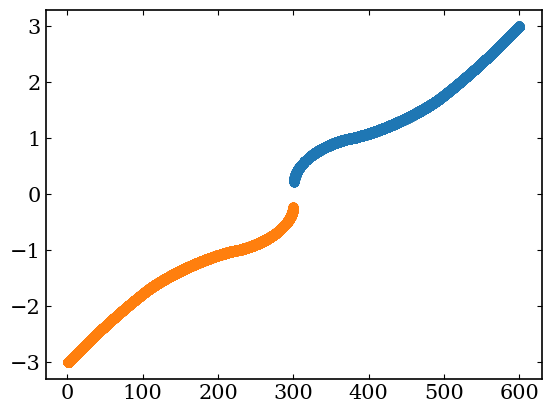

In [15]:
ev_plus = np.sort(E_plus.flatten()/t1)
ev_minus = np.sort(E_minus.flatten()/t1)
n_minus = np.linspace(1,300,90000)
n_plus = np.linspace(301,600,90000)

plt.scatter(n_plus, ev_plus)
plt.scatter(n_minus, ev_minus)

